Required Components
Each project must include:
✔ Artificial Neural Network (ANN) or Autoencoder
✔ Regularization techniques (L2, Dropout, Early Stopping, etc.)
✔ Hyperparameter tuning (manual or Keras Tuner)
✔ Proper evaluation metrics
✔ Model saving & loading

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import seaborn as sns

In [ ]:
pip install kaggle

dataset consists of reviews of fine foods from amazon. The data span a period of more than 10 years, including all ~500,000 reviews up to October 2012. Reviews include product and user information, ratings, and a plain text review. It also includes reviews from all other Amazon categories.

In [ ]:
import kagglehub
import pandas as pd
import os
from google.colab import files
files.upload()





Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"bayanalfarsi","key":"b06ce02642b9b2f4f688ac657d443705"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Data loading and preprocessing

In [ ]:
df = pd.read_csv(
    "Reviews.csv",
    on_bad_lines='skip', # Skips the rows that cause the error
    engine="python"      # The python engine is slower but better at handling messy text
)

print(f"Loaded {len(df)} rows.")
df.head()

Loaded 568454 rows.


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
!kaggle datasets download -d snap/amazon-fine-food-reviews

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
License(s): CC0-1.0
100% 242M/242M [00:03<00:00, 76.0MB/s]



In [ ]:
!unzip amazon-fine-food-reviews.zip

Archive:  amazon-fine-food-reviews.zip
  inflating: Reviews.csv             
  inflating: database.sqlite         
  inflating: hashes.txt              


In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [ ]:
# Fill nulls in the Summary column
df['Summary'] = df['Summary'].fillna("none")

# Convert timestamp to a readable year
from sklearn.preprocessing import MinMaxScaler

df['Year'] = pd.to_datetime(df['Time'], unit='s').dt.year

# Scale
scaler = MinMaxScaler()
df['Year_Scaled'] = scaler.fit_transform(df[['Year']])

# Now drop the original 'Time' and 'Year' to save memory
df.drop(columns=['Time', 'Year'], inplace=True)
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,Year_Scaled
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,0.923077
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,1.000000
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,"""Delight"" says it all",This is a confection that has been around a fe...,0.692308
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,Cough Medicine,If you are looking for the secret ingredient i...,0.923077
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,Great taffy,Great taffy at a great price. There was a wid...,1.000000
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,Will not do without,Great for sesame chicken..this is a good if no...,0.923077
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,disappointed,I'm disappointed with the flavor. The chocolat...,1.000000
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",1.000000
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,Favorite Training and reward treat,These are the BEST treats for training and rew...,1.000000


Numerator <= Denominator.
they provide weight to the Score.

In [ ]:
df.duplicated().sum()
#df.drop_duplicates()

np.int64(0)

In [ ]:
df["Score"].value_counts().sort_index()

,count
Score,
1,52268
2,29769
3,42640
4,80655
5,363122


show possible skewness and data imbalance

# scaling

In [ ]:
# numercal : Numerator Denominator (year already scaled)

scaler =StandardScaler()
df[["HelpfulnessNumerator"]]=scaler.fit_transform(df[["HelpfulnessNumerator"]])
df[["HelpfulnessDenominator"]]=scaler.fit_transform(df[["HelpfulnessDenominator"]])

# categorical : text , summary (needs clean, tokenize, and embed)

df['Full_Review'] = df['Summary'].fillna('') + " " + df['Text'].fillna('')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text) # remove HTML tags (common in Amazon data)
    text = re.sub(r'[^a-z0-9\s]', '', text) # remove special characters/punctuation
    return text

df['Full_Review'] = df['Full_Review'].apply(clean_text)

#tokenize
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Full_Review'])

# convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df['Full_Review'])

# Pad sequences to ensure uniform length
sequences = tokenizer.texts_to_sequences(df['Full_Review'])
X_text = pad_sequences(sequences, maxlen=100, padding='post')

#embeding in the model


# model

In [ ]:
X=df[["HelpfulnessNumerator","HelpfulnessDenominator","Year_Scaled"]]

y=df["Score"]

#Multi-Input ANN
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text,      # Text sequences
    X,           # Numeric features (Numerator, Denominator, Year)
    y,           # Target (Score)
    test_size=0.25,
    random_state=42,
    stratify=y   # Keeps the 64% 5-star ratio consistent in both sets
)

# Convert 1-5 to 0-4
y_train = y_train - 1
y_test = y_test - 1


autoencoder

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model


input_num = layers.Input(shape=(3,))
# Encoder
enc = layers.Dense(16, activation='relu')(input_num)
enc = layers.Dense(8, activation='relu')(enc)
bottleneck = layers.Dense(2, activation='relu', name="bottleneck")(enc)#flatten
# Decoder
dec = layers.Dense(8, activation='relu')(bottleneck)
dec = layers.Dense(16, activation='relu')(dec)
output_num = layers.Dense(3, activation='linear')(dec) #output actual values, not just 0 or 1

autoencoder = Model(input_num, output_num)
autoencoder.compile(optimizer='adam', loss='mse')

#  Train Autoencoder
#x and y are BOTH X_num_train because we are reconstructing the input
autoencoder.fit(X_num_train, X_num_train, epochs=20, batch_size=64, validation_split=0.1)

#Create the Encoder (Feature Extractor)
encoder = Model(input_num, bottleneck)


Epoch 1/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0264 - val_loss: 0.0104
Epoch 2/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0113 - val_loss: 0.0117
Epoch 3/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.0130 - val_loss: 0.0104
Epoch 4/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0108 - val_loss: 0.0103
Epoch 5/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0116 - val_loss: 0.0107
Epoch 6/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0114 - val_loss: 0.0099
Epoch 7/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0106 - val_loss: 0.0100
Epoch 8/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0109 - val_loss: 0.0102
Epoch 9/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.0107 - val_loss: 0.0097
Epoch 10/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0108 - val_loss: 0.0097
Epoch 11/20
5996/5996 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.0104 - val_loss: 0.0100
Epoch 12/20
5996/59

-val_loss is consistently lower than or equal to the loss. This suggests the model is generalizing well and isn't overfitting to the training data.

-From Epoch 14 to 20, the loss  stays the same. This means the model has "found" the mathematical relationship between how helpful a review is and when it was posted

In [ ]:
# Convert your 3D numeric data into a 2D "Latent Representation"
#feature extraction
X_num_train_encoded = encoder.predict(X_num_train)
X_num_test_encoded = encoder.predict(X_num_test)

13324/13324 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
4442/4442 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


In [ ]:
print(f"Original shape: {X_num_train.shape}")
print(f"Encoded shape: {X_num_train_encoded.shape}")

Original shape: (426340, 3)
Encoded shape: (426340, 2)


build multi input ANN

In [ ]:
from tensorflow.keras import layers, Model

# TEXT INPUT
text_input = layers.Input(shape=(100,), name="Text_Input")
t = layers.Embedding(input_dim=10000, output_dim=64)(text_input)
t = layers.Bidirectional(layers.LSTM(32))(t)
t = layers.Dropout(0.3)(t)

# ENCODED NUMERIC INPUT
# Note the shape is (2,) now because the autoencoder compressed it
encoded_input = layers.Input(shape=(2,), name="Encoded_Numeric_Input")
n = layers.Dense(16, activation='relu')(encoded_input)

# --- MERGE & CLASSIFY ---
combined = layers.Concatenate()([t, n])
z = layers.Dense(32, activation='relu')(combined)
z = layers.Dropout(0.3)(z)

# Output for 5 classes (Score 0-4)
output = layers.Dense(5, activation='softmax')(z)

final_model = Model(inputs=[text_input, encoded_input], outputs=output)

final_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# 1. Calculate the 'balanced' weights
# This looks at how many 0s, 1s, 2s, 3s, and 4s are in your y_train
weights = class_weight.compute_class_weight(#Class Weights forced the model to be a "fair"
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 2. Turn those weights into a dictionary that Keras understands
# Format: {0: weight_for_score_1, 1: weight_for_score_2, ...}
weight_dict = dict(enumerate(weights))

print("Class Weights:", weight_dict)

Class Weights: {0: np.float64(2.175148593148134), 1: np.float64(3.819053164330183), 2: np.float64(2.6662914321450906), 3: np.float64(1.409598122034683), 4: np.float64(0.3130927770699234)}


In [ ]:
# Train using the encoded numeric features as the second input
history = final_model.fit(
    x=[X_text_train, X_num_train_encoded],
    y=y_train,
    validation_data=([X_text_test, X_num_test_encoded], y_test),
    epochs=15,
    batch_size=128,
    class_weight=weight_dict, # Using the weights we calculated earlier
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/15
3331/3331 ━━━━━━━━━━━━━━━━━━━━ 464s 138ms/step - accuracy: 0.6279 - loss: 1.1039 - val_accuracy: 0.6718 - val_loss: 0.8139
Epoch 2/15
3331/3331 ━━━━━━━━━━━━━━━━━━━━ 545s 151ms/step - accuracy: 0.6792 - loss: 0.9318 - val_accuracy: 0.7109 - val_loss: 0.7600
Epoch 3/15
3331/3331 ━━━━━━━━━━━━━━━━━━━━ 459s 138ms/step - accuracy: 0.7026 - loss: 0.8447 - val_accuracy: 0.6674 - val_loss: 0.8326
Epoch 4/15
3331/3331 ━━━━━━━━━━━━━━━━━━━━ 459s 138ms/step - accuracy: 0.7189 - loss: 0.7759 - val_accuracy: 0.7190 - val_loss: 0.7226
Epoch 5/15
3331/3331 ━━━━━━━━━━━━━━━━━━━━ 459s 138ms/step - accuracy: 0.7336 - loss: 0.7161 - val_accuracy: 0.6709 - val_loss: 0.7962
Epoch 6/15
3331/3331 ━━━━━━━━━━━━━━━━━━━━ 464s 139ms/step - accuracy: 0.7442 - loss: 0.6662 - val_accuracy: 0.6898 - val_loss: 0.7980
Epoch 7/15
3331/3331 ━━━━━━━━━━━━━━━━━━━━ 459s 138ms/step - accuracy: 0.7545 - loss: 0.6195 - val_accuracy: 0.7033 - val_loss: 0.7619


The val_loss reached its lowest point at Epoch 4 (0.7226) and then started climbing back up. stopped at Epoch 7. Because we used restore_best_weights=True, your final_model currently holds the weights from Epoch 4, which is your most balanced and generalized version.

confusion matrix

4442/4442 ━━━━━━━━━━━━━━━━━━━━ 94s 21ms/step
              precision    recall  f1-score   support

      1 Star       0.70      0.75      0.72     13067
      2 Star       0.47      0.55      0.51      7442
      3 Star       0.50      0.60      0.55     10660
      4 Star       0.39      0.59      0.47     20164
      5 Star       0.92      0.77      0.84     90781

    accuracy                           0.72    142114
   macro avg       0.60      0.65      0.62    142114
weighted avg       0.77      0.72      0.74    142114



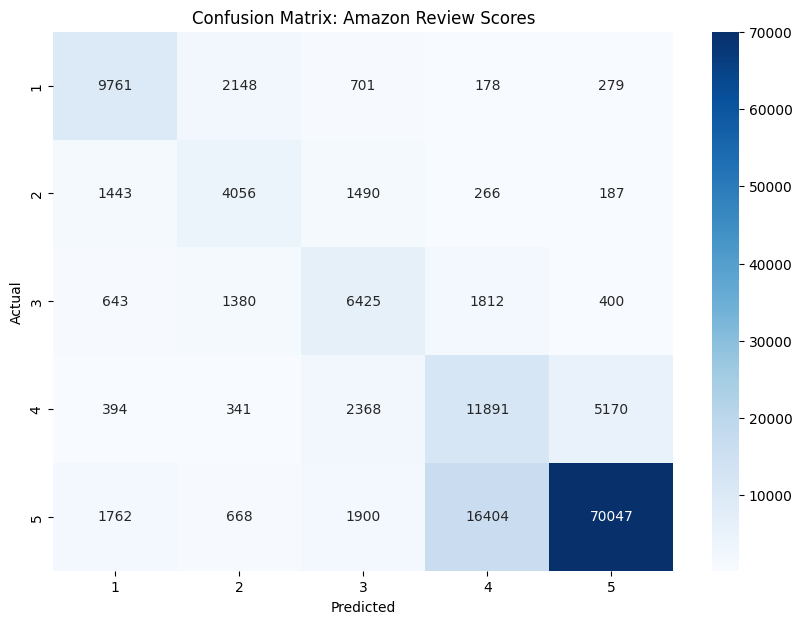

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report


# get predictions
y_pred_probs = final_model.predict([X_text_test, X_num_test_encoded])
y_pred = np.argmax(y_pred_probs, axis=1)

# Remember to use the 0-indexed y_test
print(classification_report(y_test, y_pred, target_names=['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']))

#  Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1', '2', '3', '4', '5'],
            yticklabels=['1', '2', '3', '4', '5'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Amazon Review Scores')
plt.show()

5-Star (0.84 F1-Score): The model is excellent here. A precision of 0.92 means when the model says a review is 5-star, it is almost always right.

1-Star (0.72 F1-Score): This is a huge win. eventhoug the data is imbalanced, model is identifying 1-star reviews with 75% recall.